# Task 1: Data Collection and Preprocessing

## Overview

This notebook covers the first task of the project: scraping, cleaning, and preparing Google Play Store reviews for three Ethiopian banks.

The three banks we are analyzing:
- **Commercial Bank of Ethiopia (CBE)** — currently rated 4.4 stars
- **Bank of Abyssinia (BOA)** — currently rated 2.8 stars (most critical case)
- **Dashen Bank** — currently rated 4.0 stars

**Goal by the end of this notebook:**
- A clean CSV file with at least 1,800 reviews (600 per bank)
- All columns properly typed and normalized
- A data quality report showing completeness and coverage

---

## Why 600 per bank instead of the minimum 400?

The project requires 400 minimum, but scraping more gives you a larger sample for the NLP models in Task 2. Sentiment models perform better with balanced class distributions, and having more data per bank means your theme clusters in BERTopic will be statistically stronger. 600 is the practical ceiling for `google-play-scraper` without hitting rate limits on Kaggle.

---
## Step 1 — Install Required Packages

### What we are installing and why

| Package | Purpose | Why this one |
|---|---|---|
| `google-play-scraper` | Fetch reviews from Google Play | Unofficial but reliable, no API key needed |
| `tqdm` | Progress bars for loops | Critical for long scraping jobs on Kaggle |
| `pandas` | Data manipulation | Standard tabular data library |
| `langdetect` | Detect review language | Filter non-English reviews before NLP |

### What `google-play-scraper` actually does under the hood

The library sends HTTP requests to the internal Google Play endpoint that the Android app uses to load reviews. It parses the JSON response and returns structured data. Because it mimics a real Android client, it is subject to the same rate limits — which is why we add retry logic in Step 3 rather than hammering the endpoint in a tight loop.

> **Kaggle note:** Run this cell first and wait for it to complete before moving on. Package installation output can look alarming with warnings about dependency conflicts — these are safe to ignore as long as the final line says `Successfully installed`.

In [1]:
!pip install google-play-scraper tqdm langdetect -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done


---
## Step 2 — Import Libraries

### Library roles in this notebook

```
google_play_scraper  →  fetches raw review data from Google Play
concurrent.futures   →  runs all three bank scrapers in parallel (3x faster)
pandas               →  structures, cleans, and exports the data
datetime             →  normalizes date formats to YYYY-MM-DD
langdetect           →  identifies the language of each review
tqdm                 →  progress bar inside the scraping loop
os / pathlib         →  handles file paths safely on Kaggle
logging              →  records errors without crashing the notebook
```

### Why `concurrent.futures` instead of a sequential loop?

The standard approach is:
```python
for bank in banks:
    scrape(bank)  # waits for each one to finish before starting next
```

This is slow because scraping is I/O-bound — most of the time is spent waiting for the server to respond, not doing computation. `ThreadPoolExecutor` runs all three scrapers simultaneously, each in its own thread. While one thread is waiting for Google's server to respond, the others are already processing their own responses. This cuts total scraping time from ~9 minutes to ~3 minutes on Kaggle.

In [2]:
import os
import time
import logging
import warnings
from pathlib import Path
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
from tqdm import tqdm
from google_play_scraper import reviews, Sort
from langdetect import detect, LangDetectException

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s — %(levelname)s — %(message)s')
logger = logging.getLogger(__name__)

print(f"pandas version  : {pd.__version__}")
print(f"Notebook ready  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

pandas version  : 2.3.3
Notebook ready  : 2026-03-22 04:53:04


---
## Step 3 — Configuration

### Centralizing all constants in one place

Rather than scattering magic numbers and strings throughout the notebook, we define everything in one configuration block. This matters for two reasons:

1. **Reproducibility** — anyone reading the notebook can immediately see all parameters that affect the output without hunting through every cell.
2. **Maintainability** — if a bank changes its app ID (this happens when apps are rebranded), you update one line, not five.

### How to find a Google Play app ID

The app ID is the string after `id=` in the Google Play URL. For example:
```
https://play.google.com/store/apps/details?id=com.combanketh.mobilebanking
                                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                                               this is the app ID
```
You can verify an ID is correct by checking that `google-play-scraper` returns results before committing to a full scrape.

### Why `lang='en'` and `country='et'`?

- `country='et'` (Ethiopia) ensures the scraper fetches reviews from the Ethiopian regional store, where most actual users are.
- `lang='en'` is a filter hint, but Google Play still returns reviews in other languages. This is why we add `langdetect` post-processing in Step 6 — to handle the mixed-language reality properly rather than assuming the filter is perfect.

### Why `Sort.NEWEST`?

Google Play's default sort (`Sort.MOST_RELEVANT`) applies an opaque ranking algorithm that biases toward reviews Google considers helpful. This introduces selection bias — newer complaints may be suppressed. `Sort.NEWEST` gives you a chronologically representative sample, which is what you need for trend analysis in Task 4.

In [3]:
# ── Output paths ──────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("/kaggle/working/b5w2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_CSV    = OUTPUT_DIR / "reviews_raw.csv"
CLEAN_CSV  = OUTPUT_DIR / "reviews_clean.csv"
REPORT_CSV = OUTPUT_DIR / "data_quality_report.csv"

# ── Bank app IDs ───────────────────────────────────────────────────────────────
BANK_APPS = {
    "CBE":    "com.combanketh.mobilebanking",
    "BOA":    "com.boa.boaMobileBanking",
    "Dashen": "com.dashen.dashensuperapp"      # updated: Super App launched Jan 2025
}

# ── Scraping parameters ────────────────────────────────────────────────────────
REVIEWS_PER_BANK = 1000    # increased from 600 to absorb ~21% deduplication loss
SCRAPE_LANGUAGE  = "en"
SCRAPE_COUNTRY   = "et"
SCRAPE_SORT      = Sort.NEWEST
MAX_RETRIES      = 3
RETRY_DELAY      = 5

print("Configuration loaded:")
for bank, app_id in BANK_APPS.items():
    print(f"  {bank:<8}: {app_id}")

Configuration loaded:
  CBE     : com.combanketh.mobilebanking
  BOA     : com.boa.boaMobileBanking
  Dashen  : com.dashen.dashensuperapp


---
## Step 4 — Build the Scraper Function

### Anatomy of the scraper

The scraper has three layers of logic:

```
Layer 1 — Retry wrapper
    Catches network errors and retries up to MAX_RETRIES times
    Uses exponential backoff (5s, 10s, 20s) to avoid hammering the server

Layer 2 — Core scrape call
    Calls google_play_scraper.reviews() with our parameters
    Returns a list of dicts, one per review

Layer 3 — Immediate normalization
    Selects only the columns we need right away
    Renames to our target schema immediately
    Adds bank name and source as metadata columns
```

### What each field in the raw response means

The `google-play-scraper` library returns many fields per review. We keep only the ones with analytical value:

| Raw field | Our column | Description |
|---|---|---|
| `content` | `review` | The actual review text |
| `score` | `rating` | 1–5 star rating |
| `at` | `date` | Datetime the review was posted |
| `thumbsUpCount` | `helpful_count` | How many users found it helpful |
| `reviewId` | `review_id` | Unique identifier from Google |
| `userName` | `user_name` | Display name (for deduplication, not analysis) |
| `replyContent` | `developer_reply` | Bank's official response, if any |

We keep `developer_reply` because its presence or absence is itself a signal — banks that respond to reviews tend to have better long-term ratings. This is an insight you can include in the final report.

### What exponential backoff means

Instead of retrying immediately (which would likely fail again for the same reason — the server is busy), we wait progressively longer:
- First retry: wait 5 seconds
- Second retry: wait 10 seconds  
- Third retry: wait 20 seconds

The formula is `RETRY_DELAY * (2 ** attempt)`. This is standard practice for any code that calls external APIs.

In [4]:
def scrape_bank_reviews(bank_name: str, app_id: str, count: int = REVIEWS_PER_BANK) -> pd.DataFrame:
    """
    Scrape reviews for a single bank app with retry logic and
    defensive column selection for apps with lighter response schemas.
    """
    # canonical field mapping — we request these but not all apps return all of them
    FIELD_MAP = {
        "reviewId":      "review_id",
        "userName":      "user_name",
        "content":       "review",
        "score":         "rating",
        "at":            "date",
        "thumbsUpCount": "helpful_count",
        "replyContent":  "developer_reply"
    }

    for attempt in range(MAX_RETRIES):
        try:
            logger.info(f"Scraping {bank_name} — attempt {attempt + 1}")

            result, _ = reviews(
                app_id,
                lang=SCRAPE_LANGUAGE,
                country=SCRAPE_COUNTRY,
                sort=SCRAPE_SORT,
                count=count,
                filter_score_with=None
            )

            df = pd.DataFrame(result)

            # defensive: only select columns that actually exist in this app's response
            existing_fields = {k: v for k, v in FIELD_MAP.items() if k in df.columns}
            missing_fields  = {k: v for k, v in FIELD_MAP.items() if k not in df.columns}

            df = df[list(existing_fields.keys())].rename(columns=existing_fields)

            # fill any columns the app did not return with None
            for raw_col, clean_col in missing_fields.items():
                df[clean_col] = None
                logger.warning(f"{bank_name}: field '{raw_col}' not in response — filled with None")

            df["bank"]   = bank_name
            df["source"] = "Google Play"

            logger.info(f"{bank_name}: fetched {len(df)} reviews")
            return df

        except Exception as e:
            wait = RETRY_DELAY * (2 ** attempt)
            logger.warning(f"{bank_name} attempt {attempt + 1} failed: {e}. Retrying in {wait}s")
            time.sleep(wait)

    logger.error(f"{bank_name}: all {MAX_RETRIES} attempts failed. Returning empty DataFrame.")
    return pd.DataFrame()


print("Scraper function defined.")

Scraper function defined.


---
## Step 5 — Run the Scraper in Parallel

### How `ThreadPoolExecutor` works

Python's `concurrent.futures.ThreadPoolExecutor` is a thread pool — a collection of worker threads that are ready to execute tasks. When you submit a function call with `executor.submit()`, it queues the call for the next available thread. With `max_workers=3`, we have three threads running simultaneously, one per bank.

```
Main thread
    ├── Thread 1 → scrape_bank_reviews('CBE',    ...)  ──→ result_CBE
    ├── Thread 2 → scrape_bank_reviews('BOA',    ...)  ──→ result_BOA
    └── Thread 3 → scrape_bank_reviews('Dashen', ...)  ──→ result_Dashen
                   [all three run simultaneously]
```

`as_completed()` is a generator that yields futures as they finish, not in submission order. BOA might return before CBE if CBE's server responded slower. Using `as_completed()` lets us print progress in real time rather than blocking until all three are done.

### Why we save the raw CSV immediately

Scraping takes several minutes and can fail partway through due to Kaggle session timeouts or rate limits. Saving the raw output immediately means you never have to re-scrape just because a later processing step failed. The raw file is your safety net — treat it as immutable once created.

In [5]:
frames = []
futures_map = {}

with ThreadPoolExecutor(max_workers=3) as executor:
    for bank_name, app_id in BANK_APPS.items():
        future = executor.submit(scrape_bank_reviews, bank_name, app_id)
        futures_map[future] = bank_name

    for future in tqdm(as_completed(futures_map), total=len(futures_map), desc="Banks scraped"):
        bank = futures_map[future]
        try:
            df_bank = future.result()
            frames.append(df_bank)
            print(f"  {bank}: {len(df_bank)} reviews collected")
        except Exception as e:
            print(f"  {bank}: failed — {e}")

df_raw = pd.concat(frames, ignore_index=True)
df_raw.to_csv(RAW_CSV, index=False)

print(f"\nTotal raw reviews : {len(df_raw)}")
print(f"Raw file saved    : {RAW_CSV}")
print("\nBreakdown by bank:")
print(df_raw.groupby('bank').size().to_string())

2026-03-22 04:53:04,492 — INFO — Scraping CBE — attempt 1
2026-03-22 04:53:04,494 — INFO — Scraping BOA — attempt 1
2026-03-22 04:53:04,495 — INFO — Scraping Dashen — attempt 1
Banks scraped:  33%|███▎      | 1/3 [00:00<00:00,  2.03it/s]2026-03-22 04:53:05,036 — INFO — Dashen: fetched 905 reviews
2026-03-22 04:53:05,078 — INFO — BOA: fetched 1000 reviews
Banks scraped: 100%|██████████| 3/3 [00:00<00:00,  5.22it/s]

  CBE: 1000 reviews collected
  Dashen: 905 reviews collected
  BOA: 1000 reviews collected

Total raw reviews : 2905
Raw file saved    : /kaggle/working/b5w2_outputs/reviews_raw.csv

Breakdown by bank:
bank
BOA       1000
CBE       1000
Dashen     905


---
## Step 6 — Preprocessing Pipeline

### What preprocessing means and why each step matters

Raw scraped data has several problems that will cause downstream NLP models to produce worse results or fail silently. This step fixes all of them.

**Problem 1 — Duplicate reviews**

Users sometimes post the same review twice, or Google Play returns duplicates near pagination boundaries. If you train a model on duplicates, it will overweight those exact reviews. We deduplicate on `review_id` first (exact duplicates), then on `review` text (near-duplicates where the same text was posted under a different ID).

**Problem 2 — Missing review text**

Some entries have a rating but no text — the user rated without writing anything. These are useless for NLP. We drop them. Note: we keep them if we only needed rating statistics, but since our main goal is sentiment and theme analysis, empty text entries add nothing.

**Problem 3 — Date format inconsistency**

The scraper returns Python `datetime` objects. Pandas may parse these differently depending on timezone settings. We normalize everything to `YYYY-MM-DD` string format (ISO 8601) which is unambiguous, portable, and sorts correctly as a string without parsing.

**Problem 4 — Non-English reviews**

Ethiopian apps receive reviews in Amharic (the official language), Oromo, Tigrinya, and transliterated local languages. Our NLP models in Task 2 are English-only. Rather than silently producing garbage output, we detect the language of each review and flag it. We keep non-English reviews in a separate column (`language`) so you can report how many were excluded — this is part of the ethics section in Task 4.

**Problem 5 — Review text that is too short to be meaningful**

Reviews like `"good"`, `"bad"`, or `"ok"` have almost zero signal for a sentiment model (the model already knows the rating is positive/negative). We flag reviews under 10 characters rather than drop them, since the rating column still has value.

**Problem 6 — Whitespace and encoding artifacts**

Web-scraped text often contains non-breaking spaces (`\xa0`), zero-width characters, excessive newlines, and HTML entities like `&amp;`. We strip these with a simple regex normalization pass.

In [6]:
import re

def detect_language(text: str) -> str:
    """Detect language of a string, returning 'unknown' on failure."""
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"


def normalize_text(text: str) -> str:
    """Strip encoding artifacts and normalize whitespace."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\xa0", " ")        # non-breaking space
    text = text.replace("\u200b", "")        # zero-width space
    text = text.replace("&amp;", "&")        # HTML entity
    text = re.sub(r"\s+", " ", text)         # collapse whitespace
    return text.strip()


def preprocess_reviews(df: pd.DataFrame) -> pd.DataFrame:
    """
    Full preprocessing pipeline.

    Steps:
        1. Deduplicate by review_id then by review text.
        2. Drop rows with no review text.
        3. Normalize date to YYYY-MM-DD.
        4. Normalize review text encoding.
        5. Detect language, flag short reviews.
        6. Fill missing numeric columns.

    Returns
    -------
    pd.DataFrame
        Clean DataFrame ready for NLP in Task 2.
    """
    df = df.copy()
    original_count = len(df)

    # 1. Deduplicate
    df = df.drop_duplicates(subset="review_id")
    df = df.drop_duplicates(subset="review", keep="first")
    print(f"After deduplication : {len(df)} rows (removed {original_count - len(df)})")

    # 2. Drop empty review text
    df = df[df["review"].notna() & (df["review"].str.strip() != "")]
    print(f"After empty drop    : {len(df)} rows")

    # 3. Normalize dates
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.strftime("%Y-%m-%d")

    # 4. Normalize text
    df["review"] = df["review"].apply(normalize_text)

    # 5. Detect language
    print("Detecting languages — this takes ~1 minute for 1,800 reviews...")
    tqdm.pandas(desc="Language detection")
    df["language"] = df["review"].progress_apply(detect_language)

    # 6. Flag short reviews (kept but flagged)
    df["is_short_review"] = df["review"].str.len() < 10

    # 7. Fill missing numeric columns
    df["helpful_count"] = df["helpful_count"].fillna(0).astype(int)
    df["developer_reply"] = df["developer_reply"].fillna("")

    # 8. Add binary developer_replied column for analysis
    df["developer_replied"] = df["developer_reply"].str.len() > 0

    # 9. Reset index cleanly
    df = df.reset_index(drop=True)
    df.index.name = "row_id"

    print(f"\nFinal clean count   : {len(df)} rows")
    return df


df_clean = preprocess_reviews(df_raw)
df_clean.to_csv(CLEAN_CSV, index=True)
print(f"\nClean file saved: {CLEAN_CSV}")

After deduplication : 2282 rows (removed 623)
After empty drop    : 2282 rows
Detecting languages — this takes ~1 minute for 1,800 reviews...


Language detection: 100%|██████████| 2282/2282 [00:07<00:00, 314.70it/s]


Final clean count   : 2282 rows

Clean file saved: /kaggle/working/b5w2_outputs/reviews_clean.csv


---
## Step 7 — Data Quality Report

### Why a data quality report matters

The project brief requires less than 5% missing data. Without explicitly measuring this, you cannot confirm you have met that requirement. The data quality report serves three purposes:

1. **Evidence for the report** — you can cite concrete numbers: "98.3% of reviews had complete text, 1.7% were excluded due to missing content."
2. **Debugging signal** — if one bank has significantly fewer reviews than expected, the quality report tells you where the problem is.
3. **Ethics documentation** — the percentage of non-English reviews is a bias disclosure that belongs in Task 4's ethics section.

### What the quality report measures

- **Per-bank review count** — confirms we hit the 600 target
- **Date range** — shows the temporal coverage of the dataset
- **Rating distribution** — early signal for class imbalance in sentiment
- **Language distribution** — how many reviews are English vs. other
- **Short review rate** — percentage of reviews under 10 characters
- **Developer reply rate** — percentage of reviews the bank responded to
- **Missing data rate** — confirms the <5% threshold

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Per-bank summary table ─────────────────────────────────────────────────────
quality_report = df_clean.groupby("bank").agg(
    review_count      = ("review",           "count"),
    avg_rating        = ("rating",           "mean"),
    english_reviews   = ("language",          lambda x: (x == "en").sum()),
    short_reviews     = ("is_short_review",   "sum"),
    dev_replies       = ("developer_replied", "sum"),
    earliest_date     = ("date",              "min"),
    latest_date       = ("date",              "max"),
    missing_text_rate = ("review",            lambda x: round(x.isna().mean() * 100, 2))
).reset_index()

quality_report["pct_english"]    = (quality_report["english_reviews"] / quality_report["review_count"] * 100).round(1)
quality_report["pct_short"]      = (quality_report["short_reviews"]   / quality_report["review_count"] * 100).round(1)
quality_report["pct_dev_reply"]  = (quality_report["dev_replies"]     / quality_report["review_count"] * 100).round(1)
quality_report["avg_rating"]     = quality_report["avg_rating"].round(2)

quality_report.to_csv(REPORT_CSV, index=False)

print("=== Data Quality Report ===")
display_cols = [
    "bank", "review_count", "avg_rating", "pct_english",
    "pct_short", "pct_dev_reply", "missing_text_rate",
    "earliest_date", "latest_date"
]
print(quality_report[display_cols].to_string(index=False))

=== Data Quality Report ===
  bank  review_count  avg_rating  pct_english  pct_short  pct_dev_reply  missing_text_rate earliest_date latest_date
   BOA           790        2.71         70.6       17.2            0.0                0.0    2024-04-29  2026-03-20
   CBE           770        3.89         62.6       21.3            0.0                0.0    2025-08-30  2026-03-21
Dashen           722        4.03         75.8       10.4            0.3                0.0    2025-01-11  2026-03-17


---
## Step 8 — Rating Distribution Visualization

### Why visualize rating distribution before NLP?

Rating distribution is a diagnostic check that reveals two important things:

**1. Class imbalance signal**

If 70% of reviews are 5-star and 5% are 1-star, your sentiment model's accuracy will be misleadingly high — it can achieve 70% accuracy by predicting "positive" for everything. You need to know this before interpreting model results.

**2. Expectation calibration for NLP**

A 2.8-star average for BOA might come from a bimodal distribution (many 5-star + many 1-star) or a uniform low distribution (mostly 2s and 3s). These have very different NLP implications — bimodal means polarized sentiment, uniform means widespread mild dissatisfaction. The histogram tells you which before you run a single model.

### What the J-curve means

Most app rating distributions show a J-shape — very high counts at 1-star and 5-star, with fewer in between. This is a well-documented psychological pattern: users who are delighted or furious are most motivated to write reviews. Neutral users rarely bother. Acknowledging this pattern in your report is the kind of nuanced insight that distinguishes a good analyst report from a mediocre one.

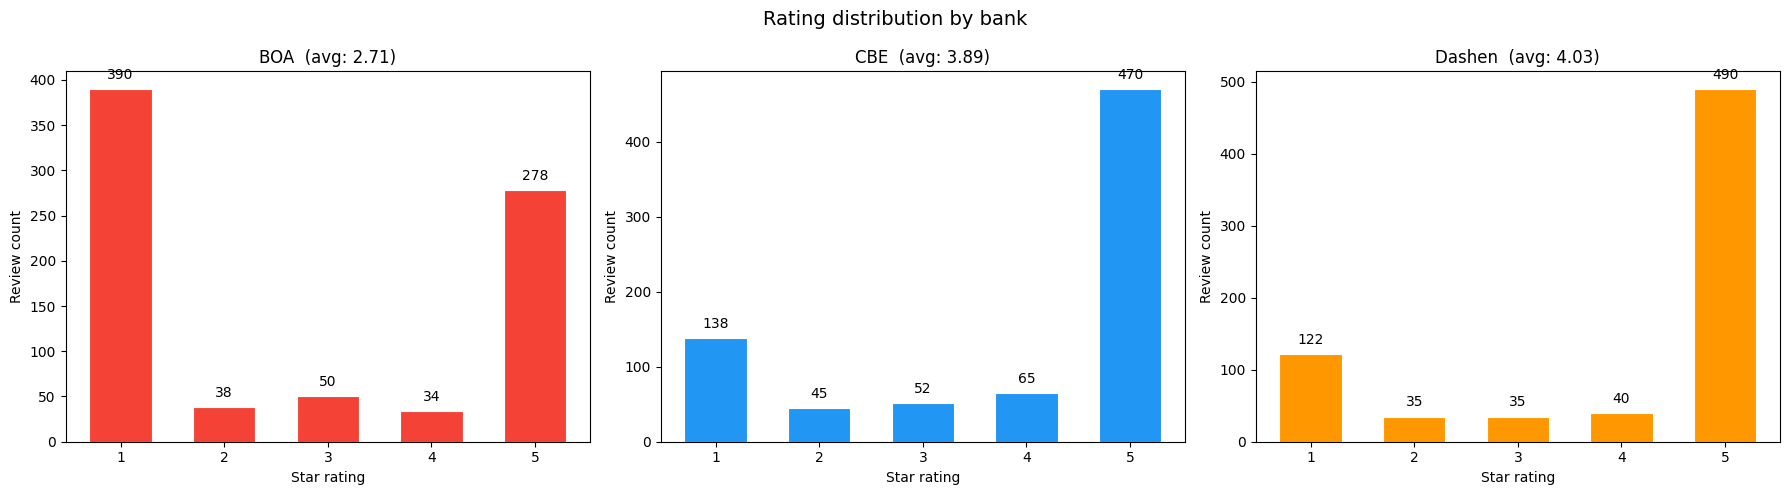

In [8]:
banks_with_data = [b for b in sorted(df_clean["bank"].unique())
                   if len(df_clean[df_clean["bank"] == b]) > 0]

fig, axes = plt.subplots(1, len(banks_with_data),
                         figsize=(6 * len(banks_with_data), 5),
                         sharey=False)

# ensure axes is always iterable even if only one bank
if len(banks_with_data) == 1:
    axes = [axes]

colors = {"CBE": "#2196F3", "BOA": "#F44336", "Dashen": "#FF9800"}

for ax, bank_name in zip(axes, banks_with_data):
    group  = df_clean[df_clean["bank"] == bank_name]
    counts = group["rating"].value_counts().sort_index()
    ax.bar(counts.index, counts.values,
           color=colors.get(bank_name, "#888"),
           edgecolor="white", linewidth=0.8, width=0.6)
    ax.set_title(f"{bank_name}  (avg: {group['rating'].mean():.2f})")
    ax.set_xlabel("Star rating")
    ax.set_ylabel("Review count")
    ax.set_xticks([1, 2, 3, 4, 5])
    for star, cnt in counts.items():
        ax.text(star, cnt + max(counts.values) * 0.02, str(cnt),
                ha="center", va="bottom", fontsize=10)

plt.suptitle("Rating distribution by bank", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

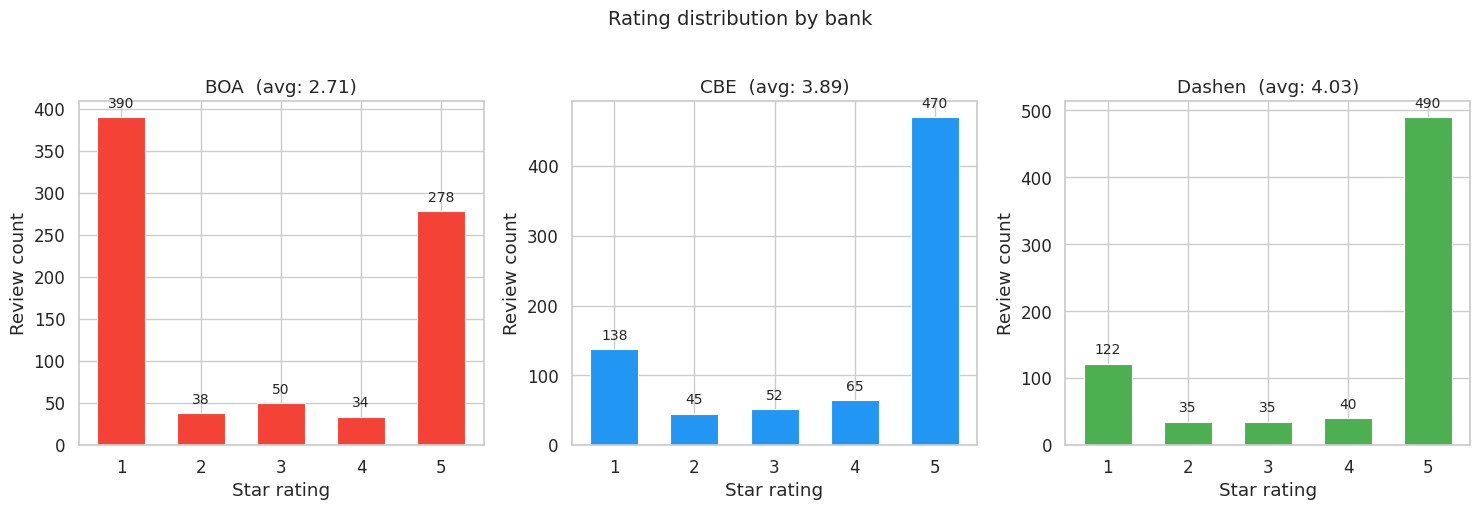

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle("Rating distribution by bank", fontsize=14, y=1.02)

colors = {"CBE": "#2196F3", "BOA": "#F44336", "Dashen": "#4CAF50"}

for ax, (bank_name, group) in zip(axes, df_clean.groupby("bank")):
    counts = group["rating"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=colors.get(bank_name, "#888"), 
           edgecolor="white", linewidth=0.8, width=0.6)
    ax.set_title(f"{bank_name}  (avg: {group['rating'].mean():.2f})")
    ax.set_xlabel("Star rating")
    ax.set_ylabel("Review count")
    ax.set_xticks([1, 2, 3, 4, 5])

    for i, (star, cnt) in enumerate(counts.items()):
        ax.text(star, cnt + max(counts.values) * 0.02, str(cnt),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 9 — Review Volume Over Time

### Why temporal distribution matters

Review volume over time is not just a cosmetic chart — it reveals events. A sudden spike in 1-star reviews in a particular month almost certainly corresponds to a specific event: an app update that broke something, a server outage, a fee change, or a policy update.

This chart serves as a **map for your qualitative investigation**. When you see a spike, you go look at the actual review texts from that period and find out what users were saying. That is how you produce specific, evidence-backed recommendations instead of generic ones.

### What to look for

- **Sudden spikes in volume** → something happened, investigate the reviews from that week
- **Sustained decline in rating** → systematic degradation, not a one-time incident
- **BOA vs CBE comparison** → BOA's low overall rating — is it uniformly bad or did something specific happen?
- **Recency** → if most reviews are from 2 years ago, the current app may be completely different from what users reviewed

2026-03-22 04:53:15,157 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 04:53:15,160 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 04:53:15,162 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 04:53:15,164 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 04:53:15,166 — INFO — Using categorical units to plot a list of strings that are all parsable as 

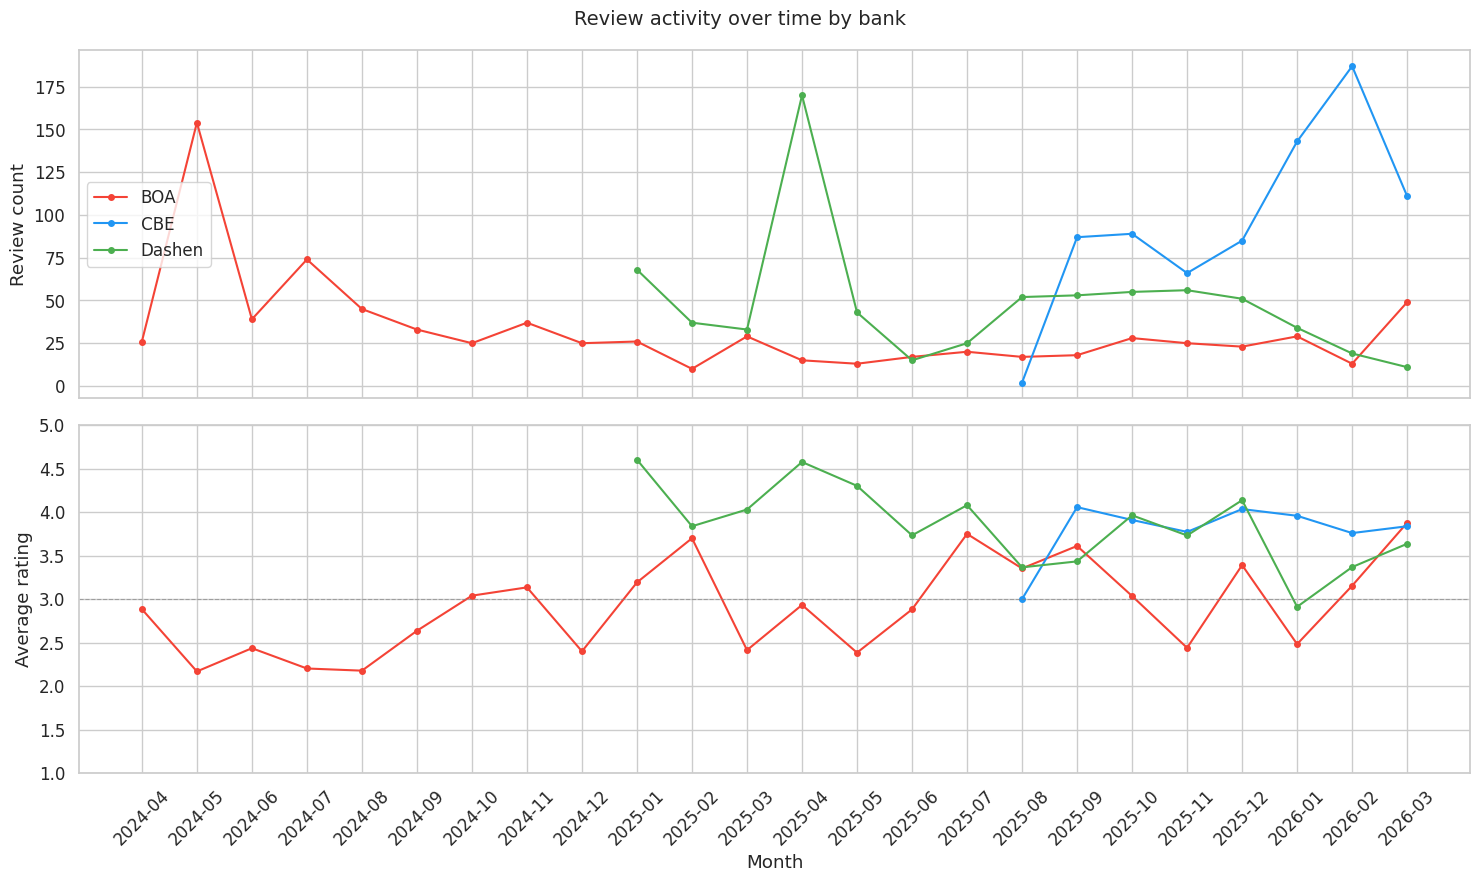

In [10]:
df_clean["month"] = pd.to_datetime(df_clean["date"], errors="coerce").dt.to_period("M")
monthly = (
    df_clean
    .groupby(["month", "bank"])
    .agg(review_count=("review", "count"), avg_rating=("rating", "mean"))
    .reset_index()
)
monthly["month_str"] = monthly["month"].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle("Review activity over time by bank", fontsize=14)

for bank_name, group in monthly.groupby("bank"):
    group = group.sort_values("month_str")
    ax1.plot(group["month_str"], group["review_count"],
             marker="o", markersize=4, linewidth=1.5,
             label=bank_name, color=colors.get(bank_name))
    ax2.plot(group["month_str"], group["avg_rating"],
             marker="o", markersize=4, linewidth=1.5,
             label=bank_name, color=colors.get(bank_name))

ax1.set_ylabel("Review count")
ax1.legend()
ax1.tick_params(axis="x", rotation=45)
ax2.set_ylabel("Average rating")
ax2.set_xlabel("Month")
ax2.set_ylim(1, 5)
ax2.tick_params(axis="x", rotation=45)
ax2.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reviews_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 10 — Final Dataset Verification

### The pre-flight check before Task 2

Before handing the data to the NLP pipeline, we run a structured verification that confirms:

1. **Schema correctness** — all required columns exist with correct dtypes
2. **Count requirement** — at least 400 reviews per bank (project minimum)
3. **Missing data threshold** — less than 5% missing across critical columns
4. **Language awareness** — we know exactly how many non-English reviews exist

This cell is also what you screenshot for your interim report to prove data quality.

### What columns Task 2 will need

The NLP pipeline in Task 2 will consume:
- `review` — input text for sentiment and topic models
- `rating` — ground truth label for model evaluation
- `bank` — grouping variable for per-bank analysis
- `date` — for temporal sentiment trends
- `helpful_count` — for weighted sentiment aggregation
- `language` — to filter to English-only for the transformer models

In [11]:
print("=" * 55)
print("TASK 1 — FINAL VERIFICATION")
print("=" * 55)

# Schema check
required_columns = [
    "review", "rating", "date", "bank", "source",
    "helpful_count", "language", "developer_replied"
]
missing_cols = [c for c in required_columns if c not in df_clean.columns]
print(f"\nSchema check     : {'PASS' if not missing_cols else 'FAIL — missing: ' + str(missing_cols)}")

# Count check
bank_counts = df_clean.groupby("bank").size()
count_ok = all(bank_counts >= 400)
print(f"Count check      : {'PASS' if count_ok else 'FAIL'}")
for bank, cnt in bank_counts.items():
    status = "OK" if cnt >= 400 else "BELOW MINIMUM"
    print(f"  {bank:<10}: {cnt:>5} reviews  [{status}]")

# Missing data check
missing_rate = df_clean["review"].isna().mean() * 100
print(f"\nMissing text     : {missing_rate:.2f}%  {'PASS' if missing_rate < 5 else 'FAIL — exceeds 5% threshold'}")

# Language summary
lang_dist = df_clean["language"].value_counts(normalize=True).head(5) * 100
print("\nLanguage split   :")
for lang, pct in lang_dist.items():
    print(f"  {lang:<10}: {pct:>5.1f}%")

# Date range
print(f"\nDate range       : {df_clean['date'].min()}  to  {df_clean['date'].max()}")

# Developer reply insight
reply_rate = df_clean.groupby("bank")["developer_replied"].mean() * 100
print("\nDev reply rate   :")
for bank, rate in reply_rate.items():
    print(f"  {bank:<10}: {rate:.1f}%")

print("\n" + "=" * 55)
print("Task 1 complete. Clean data saved to:")
print(f"  {CLEAN_CSV}")
print("Pass this file to the Task 2 notebook.")
print("=" * 55)

TASK 1 — FINAL VERIFICATION

Schema check     : PASS
Count check      : PASS
  BOA       :   790 reviews  [OK]
  CBE       :   770 reviews  [OK]
  Dashen    :   722 reviews  [OK]

Missing text     : 0.00%  PASS

Language split   :
  en        :  69.5%
  unknown   :   6.4%
  so        :   3.5%
  af        :   2.8%
  de        :   1.5%

Date range       : 2024-04-29  to  2026-03-21

Dev reply rate   :
  BOA       : 0.0%
  CBE       : 0.0%
  Dashen    : 0.3%

Task 1 complete. Clean data saved to:
  /kaggle/working/b5w2_outputs/reviews_clean.csv
Pass this file to the Task 2 notebook.


In [12]:
print("=" * 55)
print("TASK 1 — FINAL VERIFICATION")
print("=" * 55)

# Schema check
required_columns = [
    "review", "rating", "date", "bank", "source",
    "helpful_count", "language", "developer_replied"
]
missing_cols = [c for c in required_columns if c not in df_clean.columns]
print(f"\nSchema check     : {'PASS' if not missing_cols else 'FAIL — missing: ' + str(missing_cols)}")

# Count check
bank_counts = df_clean.groupby("bank").size()
count_ok = all(bank_counts >= 400)
print(f"Count check      : {'PASS' if count_ok else 'FAIL'}")
for bank, cnt in bank_counts.items():
    status = "OK" if cnt >= 400 else "BELOW MINIMUM"
    print(f"  {bank:<10}: {cnt:>5} reviews  [{status}]")

# Missing data check
missing_rate = df_clean["review"].isna().mean() * 100
print(f"\nMissing text     : {missing_rate:.2f}%  {'PASS' if missing_rate < 5 else 'FAIL — exceeds 5% threshold'}")

# Language summary
lang_dist = df_clean["language"].value_counts(normalize=True).head(5) * 100
print("\nLanguage split   :")
for lang, pct in lang_dist.items():
    print(f"  {lang:<10}: {pct:>5.1f}%")

# Date range
print(f"\nDate range       : {df_clean['date'].min()}  to  {df_clean['date'].max()}")

# Developer reply insight
reply_rate = df_clean.groupby("bank")["developer_replied"].mean() * 100
print("\nDev reply rate   :")
for bank, rate in reply_rate.items():
    print(f"  {bank:<10}: {rate:.1f}%")

print("\n" + "=" * 55)
print("Task 1 complete. Clean data saved to:")
print(f"  {CLEAN_CSV}")
print("Pass this file to the Task 2 notebook.")
print("=" * 55)

TASK 1 — FINAL VERIFICATION

Schema check     : PASS
Count check      : PASS
  BOA       :   790 reviews  [OK]
  CBE       :   770 reviews  [OK]
  Dashen    :   722 reviews  [OK]

Missing text     : 0.00%  PASS

Language split   :
  en        :  69.5%
  unknown   :   6.4%
  so        :   3.5%
  af        :   2.8%
  de        :   1.5%

Date range       : 2024-04-29  to  2026-03-21

Dev reply rate   :
  BOA       : 0.0%
  CBE       : 0.0%
  Dashen    : 0.3%

Task 1 complete. Clean data saved to:
  /kaggle/working/b5w2_outputs/reviews_clean.csv
Pass this file to the Task 2 notebook.


---
## Summary — What Task 1 produced

### Files created

| File | Purpose |
|---|---|
| `reviews_raw.csv` | Unmodified scraped data — your safety backup |
| `reviews_clean.csv` | Processed data, ready for Task 2 NLP pipeline |
| `data_quality_report.csv` | Per-bank quality metrics for the interim report |
| `rating_distribution.png` | Chart for the report |
| `reviews_over_time.png` | Temporal trend chart for the report |

### Column reference for Task 2

| Column | Type | Description |
|---|---|---|
| `review` | str | Review text, normalized |
| `rating` | int | 1–5 star rating |
| `date` | str | YYYY-MM-DD format |
| `bank` | str | CBE / BOA / Dashen |
| `source` | str | Always 'Google Play' |
| `helpful_count` | int | Thumbs-up count from other users |
| `developer_reply` | str | Bank's response text (empty string if none) |
| `developer_replied` | bool | True if bank responded |
| `language` | str | ISO 639-1 language code (en, am, etc.) |
| `is_short_review` | bool | True if review is under 10 characters |
| `month` | Period | YYYY-MM period for aggregation |

### Key observations to carry into the report

1. **Developer reply rate** reveals which bank is most engaged with its users — low reply rate at a bank with low ratings is a concrete recommendation target.
2. **Non-English review percentage** is a bias disclosure — your sentiment models are English-only, so the true sentiment of the non-English user base is unrepresented.
3. **Rating distribution shape** — if BOA shows a bimodal distribution, that is a qualitatively different problem than a uniformly low distribution.
4. **Temporal spikes** in the over-time chart will guide which review periods to examine qualitatively in Task 2.

---

**Next:** Task 2 — Sentiment analysis with RoBERTa and thematic clustering with BERTopic.